# Train Model V2 - Etape 1: chargement et etude des donnees

Dataset cible: `valakhorasani/gym-members-exercise-dataset`

Objectif de cette etape: charger le dataset puis faire une analyse exploratoire simple (shape, types, valeurs manquantes, stats, distributions).

## 0) Pre-requis (a executer si besoin)

Si ton kernel n'a pas les libs, decommenter puis executer:

```python
# !pip install pandas numpy seaborn matplotlib kagglehub
```

In [1]:
from pathlib import Path
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print('Python cwd :', Path.cwd())

Python cwd : /home/aldarion/Documents/projet_soutenance/trainer/trainer/ML


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("valakhorasani/gym-members-exercise-dataset")

print("Path to dataset files:", path)

/home/aldarion/Documents/projet_soutenance/trainer/trainer/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /home/aldarion/.cache/kagglehub/datasets/valakhorasani/gym-members-exercise-dataset/versions/1


In [3]:
# 1) Tentative de telechargement Kaggle (optionnelle)
# Cette cellule peut echouer si internet/API Kaggle indisponible dans le kernel.



dataset_slug = 'valakhorasani/gym-members-exercise-dataset'

from pathlib import Path
download_path = Path("/home/aldarion/Documents/trainer/ML")



try:
    import kagglehub
    download_path = Path(kagglehub.dataset_download(dataset_slug))
    print('Dataset telecharge dans :', download_path)
except Exception as e:
    print('Telechargement Kaggle ignore ou indisponible :', e)
    print('On passera en fallback sur un fichier local.')

    

Dataset telecharge dans : /home/aldarion/.cache/kagglehub/datasets/valakhorasani/gym-members-exercise-dataset/versions/1


In [4]:
from pathlib import Path
import shutil
import kagglehub

target_dir = Path("/home/aldarion/Documents/trainer/ML")
target_dir.mkdir(parents=True, exist_ok=True)

cache_path = Path(kagglehub.dataset_download("valakhorasani/gym-members-exercise-dataset"))
shutil.copytree(cache_path, target_dir, dirs_exist_ok=True)

download_path = target_dir
print("Dataset disponible dans :", download_path)


Dataset disponible dans : /home/aldarion/Documents/trainer/ML


In [5]:
from pathlib import Path
import pandas as pd

base_dir = Path("/home/aldarion/Documents/trainer/ML")
csv_path = base_dir / "gym_members_exercise_tracking.csv"  # adapte le nom exact

df = pd.read_csv(csv_path)
print("CSV chargé depuis :", csv_path)
df.head()


CSV chargé depuis : /home/aldarion/Documents/trainer/ML/gym_members_exercise_tracking.csv


,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39


In [6]:
# 5) Schema des donnees
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 973 entries, 0 to 972
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            973 non-null    int64  
 1   Gender                         973 non-null    str    
 2   Weight (kg)                    973 non-null    float64
 3   Height (m)                     973 non-null    float64
 4   Max_BPM                        973 non-null    int64  
 5   Avg_BPM                        973 non-null    int64  
 6   Resting_BPM                    973 non-null    int64  
 7   Session_Duration (hours)       973 non-null    float64
 8   Calories_Burned                973 non-null    float64
 9   Workout_Type                   973 non-null    str    
 10  Fat_Percentage                 973 non-null    float64
 11  Water_Intake (liters)          973 non-null    float64
 12  Workout_Frequency (days/week)  973 non-null    int64  
 13  E

In [7]:
# 6) Valeurs manquantes
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_table = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
display(missing_table[missing_table['missing_count'] > 0])

if (missing > 0).sum() == 0:
    print('Aucune valeur manquante detectee.')

,missing_count,missing_pct


Aucune valeur manquante detectee.


In [8]:
# 7) Statistiques descriptives
display(df.describe(include='all').T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,973.0,NaN,NaN,NaN,38.683453,12.180928,18.0,28.0,40.0,49.0,59.0
Gender,973,2,Male,511,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Weight (kg),973.0,NaN,NaN,NaN,73.854676,21.2075,40.0,58.1,70.0,86.0,129.9
Height (m),973.0,NaN,NaN,NaN,1.72258,0.12772,1.5,1.62,1.71,1.8,2.0
Max_BPM,973.0,NaN,NaN,NaN,179.883864,11.525686,160.0,170.0,180.0,190.0,199.0
Avg_BPM,973.0,NaN,NaN,NaN,143.766701,14.345101,120.0,131.0,143.0,156.0,169.0
Resting_BPM,973.0,NaN,NaN,NaN,62.223022,7.32706,50.0,56.0,62.0,68.0,74.0
Session_Duration (hours),973.0,NaN,NaN,NaN,1.256423,0.343033,0.5,1.04,1.26,1.46,2.0
Calories_Burned,973.0,NaN,NaN,NaN,905.422405,272.641516,303.0,720.0,893.0,1076.0,1783.0
Workout_Type,973,4,Strength,258,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
# 8) Colonnes numeriques vs categorielles
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

print('Colonnes numeriques (', len(num_cols), '):', num_cols)
print('Colonnes categorielles (', len(cat_cols), '):', cat_cols)

Colonnes numeriques ( 13 ): ['Age', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM', 'Resting_BPM', 'Session_Duration (hours)', 'Calories_Burned', 'Fat_Percentage', 'Water_Intake (liters)', 'Workout_Frequency (days/week)', 'Experience_Level', 'BMI']
Colonnes categorielles ( 2 ): ['Gender', 'Workout_Type']


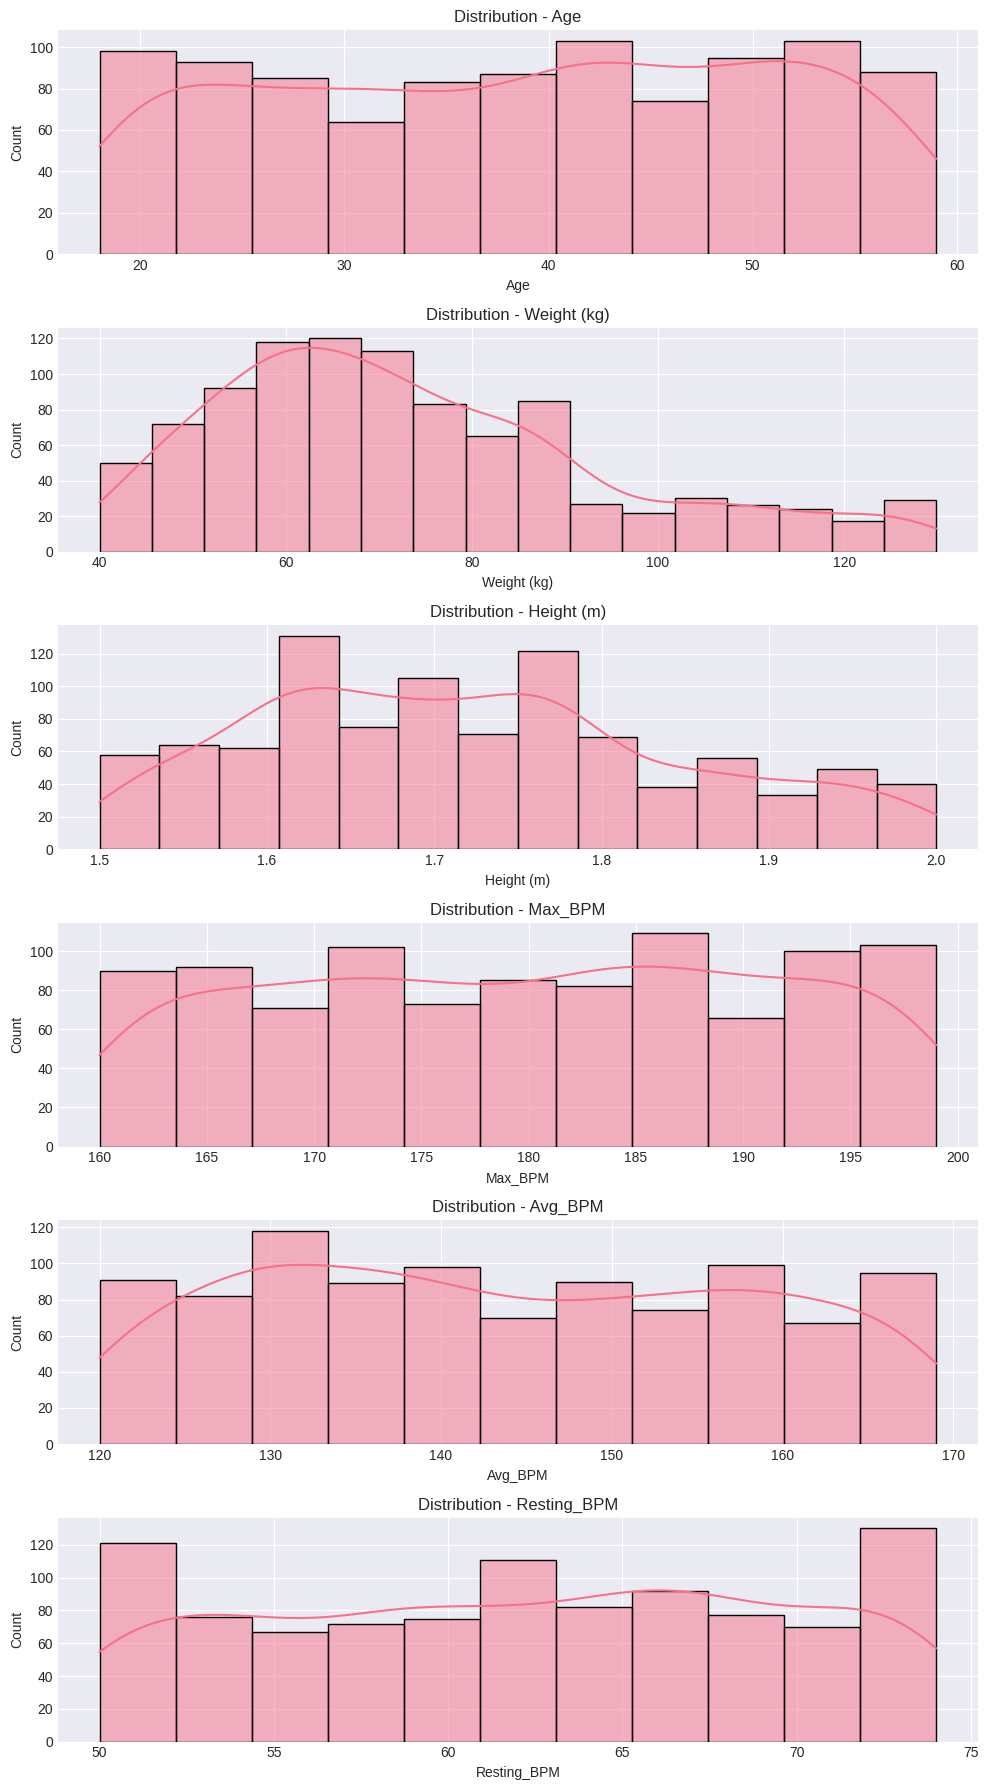

In [10]:
# 9) Distributions de base (top 6 variables numeriques)
cols_to_plot = num_cols[:6]
if cols_to_plot:
    fig, axes = plt.subplots(len(cols_to_plot), 1, figsize=(10, 3 * len(cols_to_plot)))
    if len(cols_to_plot) == 1:
        axes = [axes]
    for ax, col in zip(axes, cols_to_plot):
        sns.histplot(df[col], kde=True, ax=ax)
        ax.set_title(f'Distribution - {col}')
    plt.tight_layout()
    plt.show()
else:
    print('Aucune colonne numerique a tracer.')

## Fin etape 1

Si tout est OK, prochaine etape: nettoyage + definition des cibles + split train/test pour `train_model_V2`.

In [11]:
# 1) Créer la cible 3 classes à partir de Calories_Burned
q1, q2 = df["Calories_Burned"].quantile([0.33, 0.66])

def to_intensity(x):
    if x <= q1:
        return "faible"
    elif x <= q2:
        return "moyen"
    else:
        return "eleve"

df["intensite"] = df["Calories_Burned"].apply(to_intensity)
print(df["intensite"].value_counts())


intensite
eleve     331
moyen     321
faible    321
Name: count, dtype: int64


In [12]:
# 2) Définir X et y (on retire Calories_Burned pour éviter fuite de cible)
y = df["intensite"]
X = df.drop(columns=["intensite", "Calories_Burned"])
X


,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,Strength,29.2,2.8,3,1,14.39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
968,24,Male,87.1,1.74,187,158,67,1.57,Strength,10.0,3.5,4,3,28.77
969,25,Male,66.6,1.61,184,166,56,1.38,Strength,25.0,3.0,2,1,25.69
970,59,Female,60.4,1.76,194,120,53,1.72,Cardio,18.8,2.7,5,3,19.50
971,32,Male,126.4,1.83,198,146,62,1.10,HIIT,28.2,2.1,3,2,37.74


In [13]:
# 3) Split train/test stratifié
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("y_train distribution:\n", y_train.value_counts(normalize=True))
print("y_test distribution:\n", y_test.value_counts(normalize=True))


X_train: (778, 14) X_test: (195, 14)
y_train distribution:
 intensite
eleve     0.339332
faible    0.330334
moyen     0.330334
Name: proportion, dtype: float64
y_test distribution:
 intensite
eleve     0.343590
faible    0.328205
moyen     0.328205
Name: proportion, dtype: float64


In [14]:
# 4) Encodage des variables catégorielles
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

# aligner les colonnes
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

print("Après encodage -> X_train:", X_train.shape, "X_test:", X_test.shape)
X_train

Après encodage -> X_train: (778, 16) X_test: (195, 16)


,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI,Gender_Male,Workout_Type_HIIT,Workout_Type_Strength,Workout_Type_Yoga
367,39,63.3,1.71,178,125,56,1.88,18.5,2.7,4,3,21.65,False,False,True,False
65,48,67.1,1.61,160,151,74,0.62,33.4,1.5,2,1,25.89,False,False,False,False
232,42,50.7,1.75,163,162,51,1.29,29.0,1.9,3,2,16.56,False,False,True,False
934,52,63.6,1.62,168,150,55,1.30,20.8,2.3,4,2,24.23,True,False,True,False
261,57,126.8,1.63,161,133,73,0.96,20.8,2.1,2,1,47.72,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,52,61.5,1.69,160,152,63,1.80,15.5,2.7,4,3,21.53,False,False,False,False
707,40,70.0,1.55,171,163,74,0.85,31.1,1.5,3,1,29.14,False,False,False,True
57,21,50.3,1.52,171,154,67,1.08,32.2,2.6,3,1,21.77,False,False,False,False
650,47,43.4,1.62,179,132,64,0.51,25.3,2.3,3,1,16.54,False,False,False,False


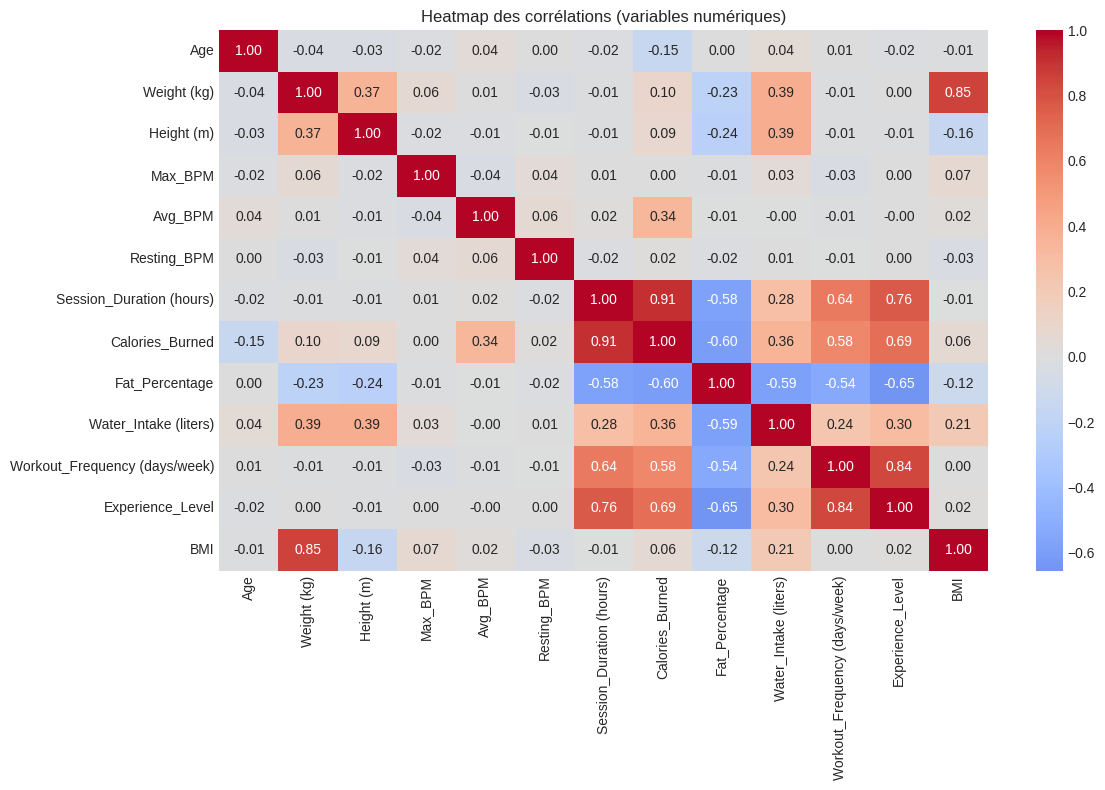

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

num_df = df.select_dtypes(include=["number"])
corr = num_df.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Heatmap des corrélations (variables numériques)")
plt.tight_layout()
plt.show()


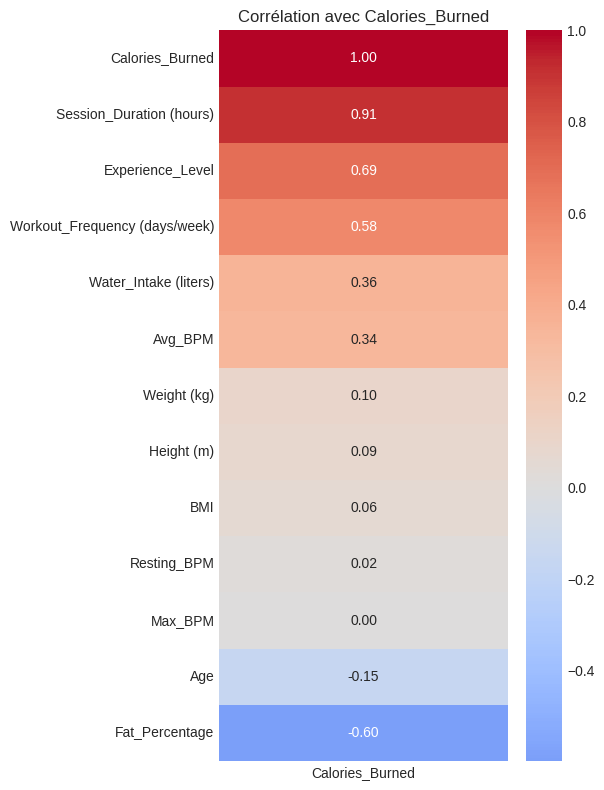

In [16]:
plt.figure(figsize=(6, 8))
corr_target = corr[["Calories_Burned"]].sort_values("Calories_Burned", ascending=False)
sns.heatmap(corr_target, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Corrélation avec Calories_Burned")
plt.tight_layout()
plt.show()


Accuracy: 0.8821
F1 macro: 0.8838

Classification report:

              precision    recall  f1-score   support

       eleve     0.9661    0.8507    0.9048        67
      faible     0.9344    0.8906    0.9120        64
       moyen     0.7733    0.9062    0.8345        64

    accuracy                         0.8821       195
   macro avg     0.8913    0.8825    0.8838       195
weighted avg     0.8924    0.8821    0.8841       195



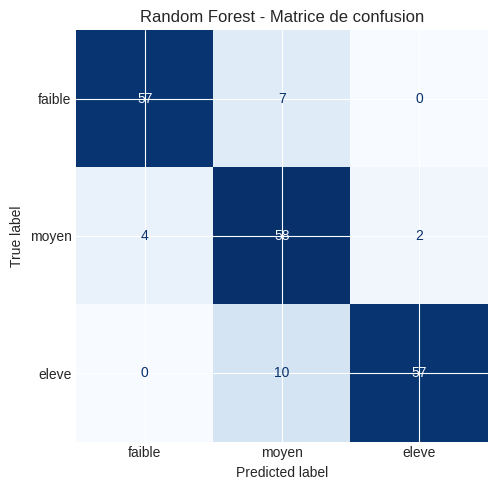

In [17]:
# Random Forest - baseline classification intensité (faible/moyen/eleve)

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score
import matplotlib.pyplot as plt

# 1) Modèle
rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    class_weight="balanced"
)

# 2) Entraînement
rf.fit(X_train, y_train)

# 3) Prédictions
y_pred = rf.predict(X_test)

# 4) Métriques
acc = accuracy_score(y_test, y_pred)
f1m = f1_score(y_test, y_pred, average="macro")

print(f"Accuracy: {acc:.4f}")
print(f"F1 macro: {f1m:.4f}")
print("\nClassification report:\n")
print(classification_report(y_test, y_pred, digits=4))

# 5) Matrice de confusion
labels = ["faible", "moyen", "eleve"]  # adapte l'ordre si besoin
cm = confusion_matrix(y_test, y_pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Random Forest - Matrice de confusion")
plt.tight_layout()
plt.show()


Lecture globale
Ton modèle est bon: Accuracy = 88.21% et F1 macro = 88.38%.
Ça veut dire qu’en moyenne, il classe correctement les 3 niveaux d’intensité.

Rappel rapide des métriques

precision = quand le modèle prédit une classe, à quel point il a raison.
recall = sur tous les vrais exemples d’une classe, combien il retrouve.
f1-score = compromis precision/recall.
Interprétation par classe

faible
Très bon (F1 = 0.912).
57/64 bien classés.
Erreur principale: 7 faible prédits moyen.
eleve
Très bon aussi (F1 = 0.905).
57/67 bien classés.
Erreur principale: 10 eleve prédits moyen.
moyen
Plus difficile (F1 = 0.835).
Recall très bon (0.9062) => il retrouve bien les vrais moyen.
Precision plus faible (0.7733) => il met souvent moyen à tort (des faible et eleve basculent vers moyen).
Ce que montre la matrice de confusion

Les erreurs sont surtout entre classes voisines (faible ↔ moyen, moyen ↔ eleve).
Presque aucune confusion directe faible ↔ eleve (0 dans les deux sens), ce qui est excellent.
Donc le modèle capte bien l’ordre d’intensité, mais la frontière autour de moyen est floue.
Conclusion “mode cours”

Modèle déjà solide pour une V1.
Le point faible logique est la classe intermédiaire moyen, souvent “zone grise”.
C’est un comportement attendu quand on crée 3 classes à partir de quantiles d’une variable continue.


,importance
Session_Duration (hours),0.344979
Avg_BPM,0.129377
Experience_Level,0.096841
Fat_Percentage,0.088708
Age,0.051431
Water_Intake (liters),0.045483
Weight (kg),0.042801
Height (m),0.036269
BMI,0.036059
Workout_Frequency (days/week),0.035049


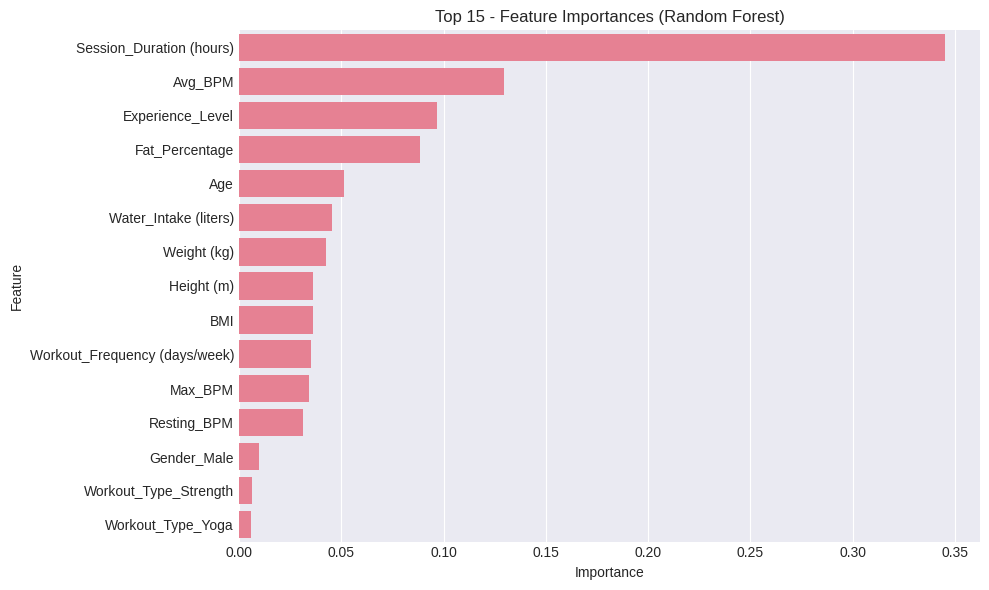

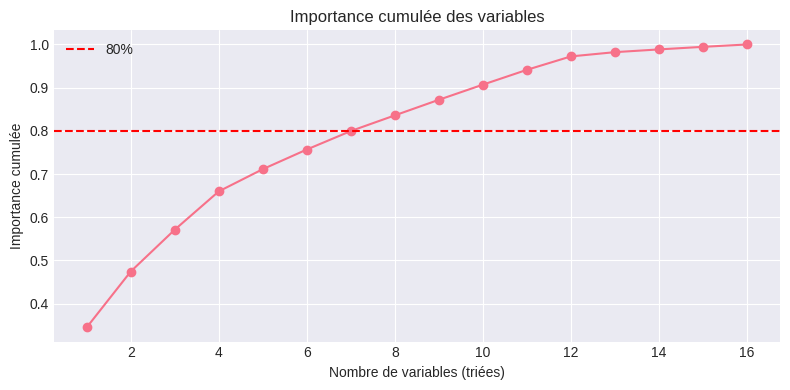

In [18]:
# Interprétation du modèle Random Forest avec les importances de variables

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1) Récupérer les importances
importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)

# 2) Afficher top features (table)
top_n = 15
display(importances.head(top_n).to_frame("importance"))

# 3) Graphe des importances
plt.figure(figsize=(10, 6))
sns.barplot(x=importances.head(top_n).values, y=importances.head(top_n).index, orient="h")
plt.title(f"Top {top_n} - Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# 4) Importance cumulée (optionnel, pour voir combien de variables expliquent l'essentiel)
cum = importances.cumsum()
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cum) + 1), cum.values, marker="o")
plt.axhline(0.8, color="red", linestyle="--", label="80%")
plt.title("Importance cumulée des variables")
plt.xlabel("Nombre de variables (triées)")
plt.ylabel("Importance cumulée")
plt.legend()
plt.tight_layout()
plt.show()


Excellent résultat, et très cohérent.

Session_Duration (hours) domine (~0.345): c’est la variable la plus utile pour distinguer faible/moyen/élevé.
Ensuite Avg_BPM, Experience_Level, Fat_Percentage apportent une forte info complémentaire.
Les variables morphologiques (Weight, Height, BMI) ont un impact moyen.
Gender et Workout_Type apportent peu ici (importances faibles).
Lecture “métier”:

Plus la séance est longue et soutenue (BPM), plus l’intensité prédite monte.
Le niveau d’expérience et la composition corporelle (fat %) jouent aussi sur la séparation des classes.
Le type d’entraînement et le genre sont secondaires dans ce dataset.
Point méthodo important:

L’importance Random Forest n’indique pas causalité, seulement utilité prédictive.
Comme ta cible vient de Calories_Burned, il est normal que Session_Duration soit très forte (corrélation structurelle avec les calories).


## Test avec XGBOOST

XGBoost Accuracy: 0.9333
XGBoost F1 macro: 0.9326

Classification report:

              precision    recall  f1-score   support

       eleve     0.9552    0.9552    0.9552        67
      faible     0.9254    0.9688    0.9466        64
       moyen     0.9180    0.8750    0.8960        64

    accuracy                         0.9333       195
   macro avg     0.9329    0.9330    0.9326       195
weighted avg     0.9332    0.9333    0.9329       195



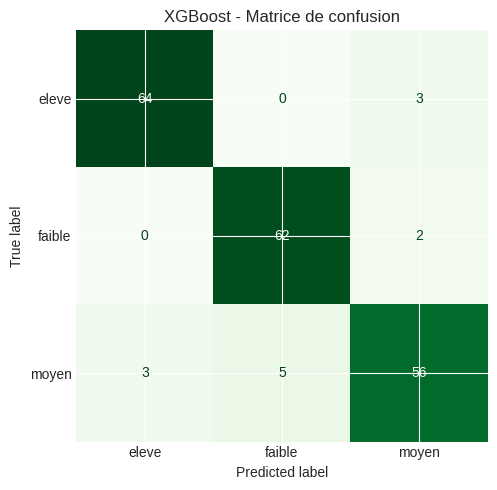

In [19]:
# 1) XGBoost - entraînement + évaluation test
# Si besoin: pip install xgboost

from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score
import matplotlib.pyplot as plt

# Encoder y en entiers (XGBoost préfère)
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

xgb = XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="multi:softprob",
    num_class=3,
    random_state=42,
    eval_metric="mlogloss"
)

xgb.fit(X_train, y_train_enc)

y_pred_enc = xgb.predict(X_test)
y_pred = le.inverse_transform(y_pred_enc)

acc = accuracy_score(y_test, y_pred)
f1m = f1_score(y_test, y_pred, average="macro")

print(f"XGBoost Accuracy: {acc:.4f}")
print(f"XGBoost F1 macro: {f1m:.4f}")
print("\nClassification report:\n")
print(classification_report(y_test, y_pred, digits=4))

labels = list(le.classes_)
cm = confusion_matrix(y_test, y_pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
fig, ax = plt.subplots(figsize=(6,5))
disp.plot(ax=ax, cmap="Greens", colorbar=False)
plt.title("XGBoost - Matrice de confusion")
plt.tight_layout()
plt.show()


In [20]:
# 2) Validation croisée (stabilité) pour RF et XGB
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
import numpy as np

# Dataset complet encodé (pour CV)
X_full = df.drop(columns=["intensite", "Calories_Burned"]).copy()
X_full = pd.get_dummies(X_full, drop_first=True)
y_full = df["intensite"].copy()
y_full_enc = LabelEncoder().fit_transform(y_full)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_cv_model = RandomForestClassifier(
    n_estimators=400,
    random_state=42,
    class_weight="balanced"
)

xgb_cv_model = XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="multi:softprob",
    num_class=3,
    random_state=42,
    eval_metric="mlogloss"
)

rf_scores = cross_val_score(rf_cv_model, X_full, y_full, cv=cv, scoring="f1_macro")
xgb_scores = cross_val_score(xgb_cv_model, X_full, y_full_enc, cv=cv, scoring="f1_macro")

print("RF CV F1 macro:", np.round(rf_scores, 4), " | mean =", rf_scores.mean().round(4))
print("XGB CV F1 macro:", np.round(xgb_scores, 4), " | mean =", xgb_scores.mean().round(4))


RF CV F1 macro: [0.8619 0.8529 0.9025 0.8619 0.8978]  | mean = 0.8754
XGB CV F1 macro: [0.8965 0.8886 0.938  0.8977 0.927 ]  | mean = 0.9095


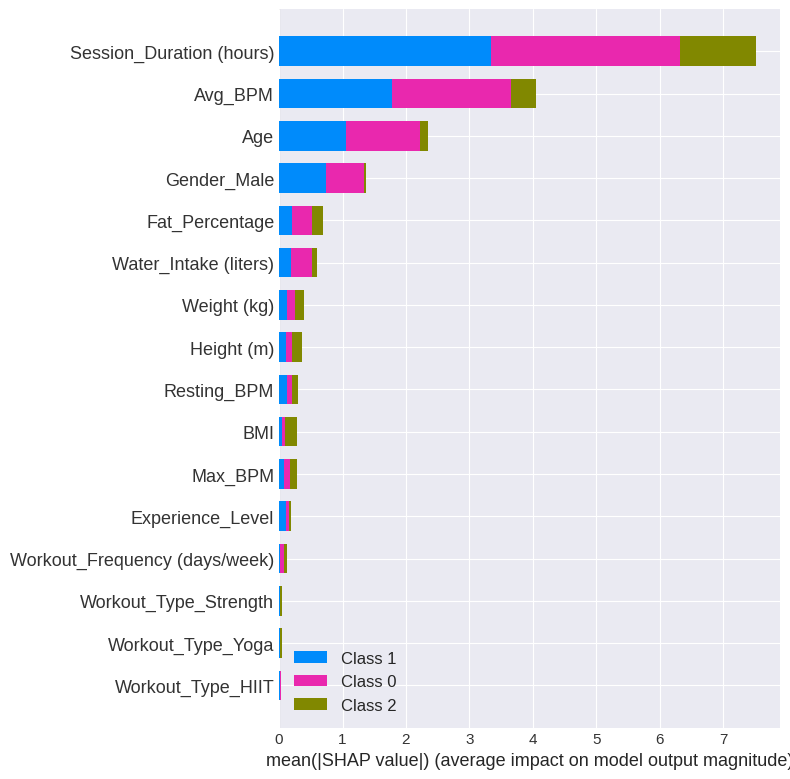

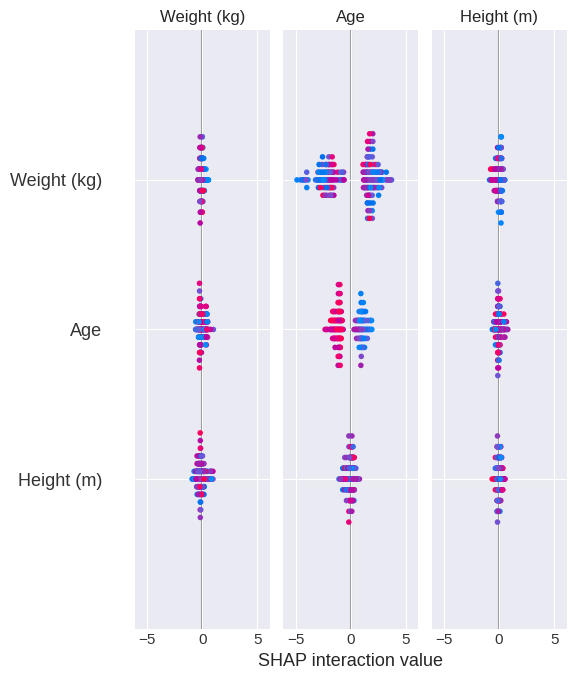

In [21]:
# 3) SHAP (optionnel) - explication du modèle XGBoost
# Si besoin: pip install shap

import shap

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

# vue globale
shap.summary_plot(shap_values, X_test, plot_type="bar")
shap.summary_plot(shap_values, X_test)


Conclusion modèle

XGBoost gagne clairement contre RandomForest.
Test set:
RF F1 macro = 0.8838
XGB F1 macro = 0.9326
Validation croisée (le plus important pour décider):
RF mean F1 macro = 0.8754
XGB mean F1 macro = 0.9095
Donc le modèle final à garder = XGBoost.

Interprétation rapide

Les classes sont bien séparées (surtout faible et eleve).
La classe moyen reste la plus ambiguë (normal: classe intermédiaire).
SHAP confirme que Session_Duration est la variable dominante, puis Avg_BPM, puis variables perso (Age, Fat%, etc.).
Point méthodo important (à mentionner dans ton rendu)
Ta cible intensite est dérivée de Calories_Burned, et Session_Duration est très corrélée à Calories_Burned. Donc excellente performance, mais il faut signaler un possible effet “proxy” (ce n’est pas une fuite directe, car Calories_Burned a bien été retirée de X).

Prochaine étape immédiate

Sauvegarder le modèle final + encodeur de labels.
Créer une cellule de prédiction sur une nouvelle observation.
(Optionnel) faire une recherche d’hyperparamètres pour gratter encore un peu de perf.

## Regression logistique

LogReg Accuracy: 0.9385
LogReg F1 macro: 0.9391

Classification report:

              precision    recall  f1-score   support

       eleve     0.9683    0.9104    0.9385        67
      faible     0.9839    0.9531    0.9683        64
       moyen     0.8714    0.9531    0.9104        64

    accuracy                         0.9385       195
   macro avg     0.9412    0.9389    0.9391       195
weighted avg     0.9416    0.9385    0.9390       195



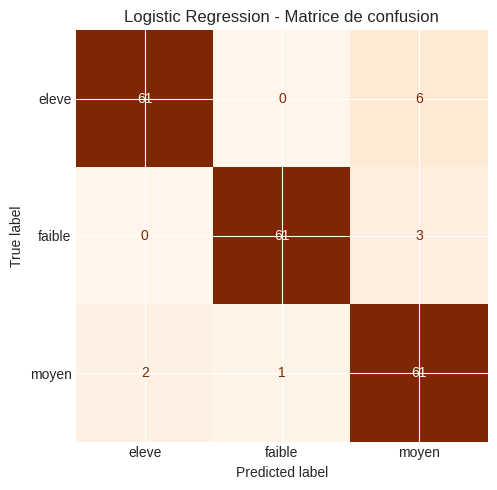

LogReg CV F1 macro: [0.9285 0.8981 0.959  0.9436 0.9485] | mean = 0.9355


In [22]:
# Logistic Regression multiclasse (baseline interprétable)

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
import numpy as np
import matplotlib.pyplot as plt

# 1) Repartir du df "brut" (avant get_dummies), avec ta cible déjà créée: df["intensite"]
X_lr = df.drop(columns=["intensite", "Calories_Burned"]).copy()
y_lr = df["intensite"].copy()

num_cols = X_lr.select_dtypes(include=["number"]).columns.tolist()
cat_cols = X_lr.select_dtypes(exclude=["number"]).columns.tolist()

# 2) Preprocessing
numeric_preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_preprocess, num_cols),
        ("cat", categorical_preprocess, cat_cols),
    ]
)

# 3) Modèle
logreg = LogisticRegression(
    solver="lbfgs",
    max_iter=3000,
    class_weight="balanced",
    random_state=42
)

pipe_lr = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", logreg)
])

# 4) Split + train/test
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X_lr, y_lr, test_size=0.2, random_state=42, stratify=y_lr
)

pipe_lr.fit(X_train_lr, y_train_lr)
y_pred_lr = pipe_lr.predict(X_test_lr)

acc = accuracy_score(y_test_lr, y_pred_lr)
f1m = f1_score(y_test_lr, y_pred_lr, average="macro")

print(f"LogReg Accuracy: {acc:.4f}")
print(f"LogReg F1 macro: {f1m:.4f}")
print("\nClassification report:\n")
print(classification_report(y_test_lr, y_pred_lr, digits=4))

labels = sorted(y_lr.unique())
cm = confusion_matrix(y_test_lr, y_pred_lr, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Oranges", colorbar=False)
plt.title("Logistic Regression - Matrice de confusion")
plt.tight_layout()
plt.show()

# 5) Validation croisée
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(pipe_lr, X_lr, y_lr, cv=cv, scoring="f1_macro")
print("LogReg CV F1 macro:", np.round(cv_scores, 4), "| mean =", cv_scores.mean().round(4))


ValueError: Unknown format code 'f' for object of type 'str'

/tmp/ipykernel_3202929/1859171564.py:109: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results, x="Modele", y="F1_macro_mean", palette="Set2")


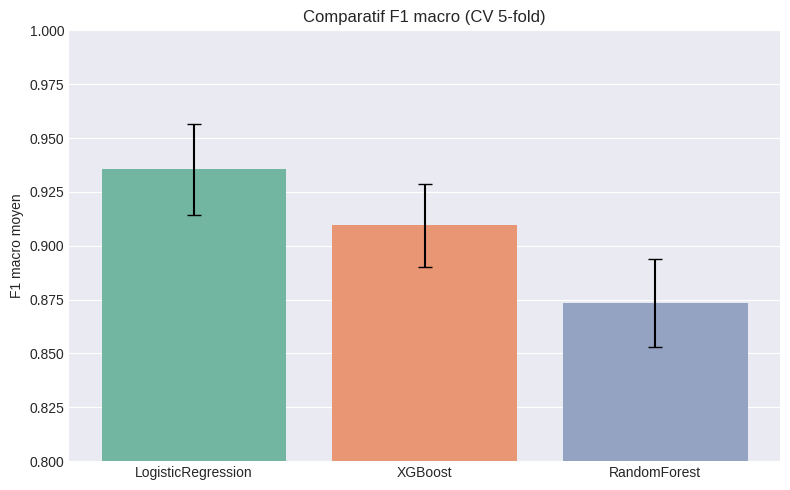

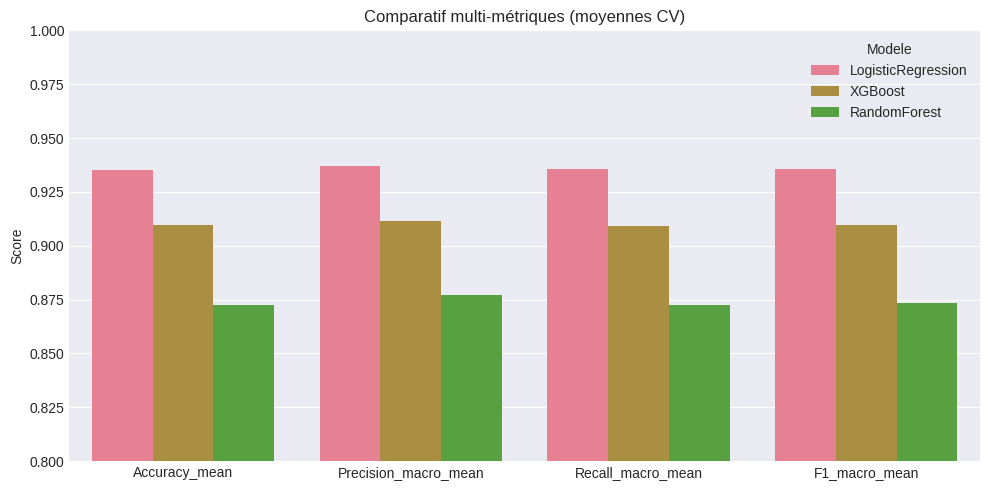

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# =========================
# 1) Préparation des données
# =========================
X = df.drop(columns=["intensite", "Calories_Burned"]).copy()
y = df["intensite"].copy()

num_cols = X.select_dtypes(include=["number"]).columns.tolist()
cat_cols = X.select_dtypes(exclude=["number"]).columns.tolist()

# Preprocess pour modèles sklearn "classiques"
preprocess = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), num_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), cat_cols)
])

# Pour XGBoost : encodage simple via get_dummies
X_xgb = pd.get_dummies(X, drop_first=True)
le = LabelEncoder()
y_xgb = le.fit_transform(y)

# =========================
# 2) Définition des modèles
# =========================
rf_pipe = Pipeline([
    ("prep", preprocess),
    ("model", RandomForestClassifier(
        n_estimators=400, random_state=42, class_weight="balanced"
    ))
])

lr_pipe = Pipeline([
    ("prep", preprocess),
    ("model", LogisticRegression(
        solver="lbfgs", max_iter=3000, class_weight="balanced", random_state=42
    ))
])

xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="multi:softprob",
    num_class=3,
    random_state=42,
    eval_metric="mlogloss"
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# =========================
# 3) Scores CV
# =========================
rf_f1 = cross_val_score(rf_pipe, X, y, cv=cv, scoring="f1_macro")
rf_acc = cross_val_score(rf_pipe, X, y, cv=cv, scoring="accuracy")
rf_prec = cross_val_score(rf_pipe, X, y, cv=cv, scoring="precision_macro")
rf_rec = cross_val_score(rf_pipe, X, y, cv=cv, scoring="recall_macro")

lr_f1 = cross_val_score(lr_pipe, X, y, cv=cv, scoring="f1_macro")
lr_acc = cross_val_score(lr_pipe, X, y, cv=cv, scoring="accuracy")
lr_prec = cross_val_score(lr_pipe, X, y, cv=cv, scoring="precision_macro")
lr_rec = cross_val_score(lr_pipe, X, y, cv=cv, scoring="recall_macro")

xgb_f1 = cross_val_score(xgb_model, X_xgb, y_xgb, cv=cv, scoring="f1_macro")
xgb_acc = cross_val_score(xgb_model, X_xgb, y_xgb, cv=cv, scoring="accuracy")
xgb_prec = cross_val_score(xgb_model, X_xgb, y_xgb, cv=cv, scoring="precision_macro")
xgb_rec = cross_val_score(xgb_model, X_xgb, y_xgb, cv=cv, scoring="recall_macro")

# =========================
# 4) Tableau récapitulatif
# =========================
results = pd.DataFrame({
    "Modele": ["RandomForest", "XGBoost", "LogisticRegression"],
    "Accuracy_mean": [rf_acc.mean(), xgb_acc.mean(), lr_acc.mean()],
    "Precision_macro_mean": [rf_prec.mean(), xgb_prec.mean(), lr_prec.mean()],
    "Recall_macro_mean": [rf_rec.mean(), xgb_rec.mean(), lr_rec.mean()],
    "F1_macro_mean": [rf_f1.mean(), xgb_f1.mean(), lr_f1.mean()],
    "F1_macro_std": [rf_f1.std(), xgb_f1.std(), lr_f1.std()]
}).sort_values("F1_macro_mean", ascending=False)

num_cols = results.select_dtypes(include="number").columns
display(results.style.format({c: "{:.4f}" for c in num_cols}))


# =========================
# 5) Graphique 1 : F1 macro (mean ± std)
# =========================
plt.figure(figsize=(8,5))
sns.barplot(data=results, x="Modele", y="F1_macro_mean", palette="Set2")
for i, row in results.reset_index(drop=True).iterrows():
    plt.errorbar(i, row["F1_macro_mean"], yerr=row["F1_macro_std"], fmt='none', c='black', capsize=5)
plt.ylim(0.80, 1.00)
plt.title("Comparatif F1 macro (CV 5-fold)")
plt.ylabel("F1 macro moyen")
plt.xlabel("")
plt.tight_layout()
plt.show()

# =========================
# 6) Graphique 2 : radar-like bar group des métriques
# =========================
plot_df = results.melt(
    id_vars="Modele",
    value_vars=["Accuracy_mean", "Precision_macro_mean", "Recall_macro_mean", "F1_macro_mean"],
    var_name="Metrique",
    value_name="Score"
)

plt.figure(figsize=(10,5))
sns.barplot(data=plot_df, x="Metrique", y="Score", hue="Modele")
plt.ylim(0.80, 1.00)
plt.title("Comparatif multi-métriques (moyennes CV)")
plt.ylabel("Score")
plt.xlabel("")
plt.tight_layout()
plt.show()
